## Task 2: Descriptive Behavior Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5) 

In [2]:
# Loading cleaned dataset

df = pd.read_csv("../data/Amazon_cleaned.csv")

print("Dataset Loaded Successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset Loaded Successfully!
Rows: 800
Columns: 25


## Age Distribution Chart

**Purpose:**
- To analyze the age distribution of respondents to understand the demographic profile of Amazon customers.


count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64


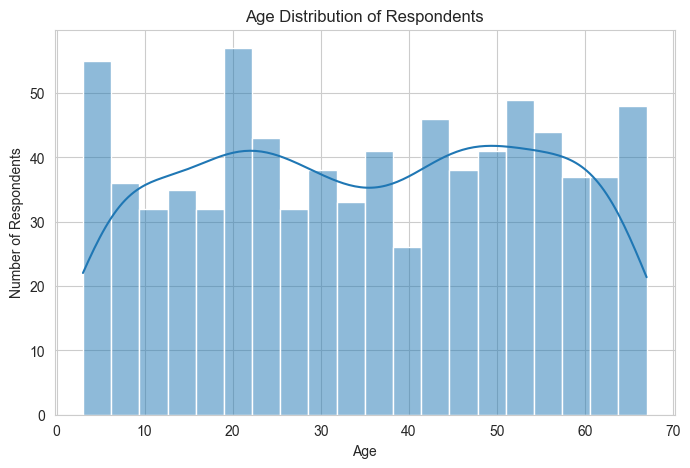

In [3]:
# Age Distribution

print(df["age"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution of Respondents")
plt.xlabel("Age")
plt.ylabel("Number of Respondents")

plt.show()

**Insight:**
- Respondents range from 3 to 67 years old.
- The average age is approximately 35 years.
- Most respondents belong to the young and middle-aged population.
- A noticeable number of respondents are below 13 years of age, indicating a potential data quality issue that should be considered during interpretation.

## Gender Distribution Chart

**Purpose:**
- To examine the distribution of respondents across different gender categories to understand the demographic composition of the survey.

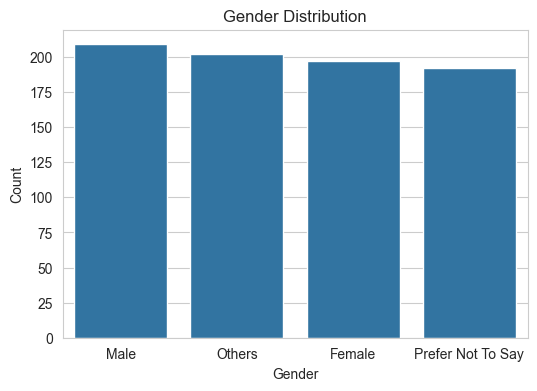

In [4]:
# Gender Distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Gender",
    order=df["Gender"].value_counts().index
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

**Insight:**
- The survey responses are fairly balanced across gender categories.
- Male respondents form the largest group, followed closely by Others, Female, and Prefer Not To Say.
- No single gender dominates the dataset, reducing demographic bias.

## Purchase Frequency Analysis


**Purpose:**
- Analyze how frequently customers purchase products on Amazon to understand overall shopping behavior and engagement.

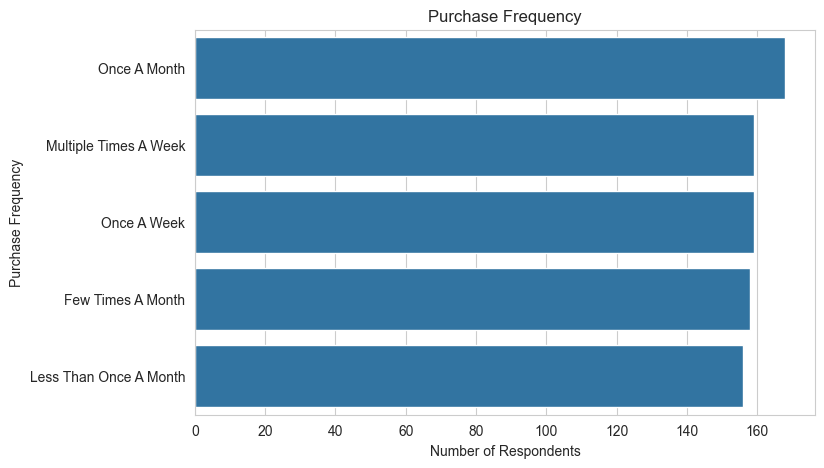

In [5]:
# Purchase Frequency Analysis

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="Purchase_Frequency",
    order=df["Purchase_Frequency"].value_counts().index
)

plt.title("Purchase Frequency")
plt.xlabel("Number of Respondents")
plt.ylabel("Purchase Frequency")

plt.show()

**Insight:**
- Customers purchasing once a month form the largest group of respondents.
- The distribution across purchase frequency categories is relatively balanced, indicating diverse shopping behaviors.
- A considerable number of customers purchase once or multiple times a week, suggesting a strong base of frequent Amazon shoppers.

## Purchase Categories Analysis

**Purpose:**
- Identify the product categories most frequently purchased by customers.

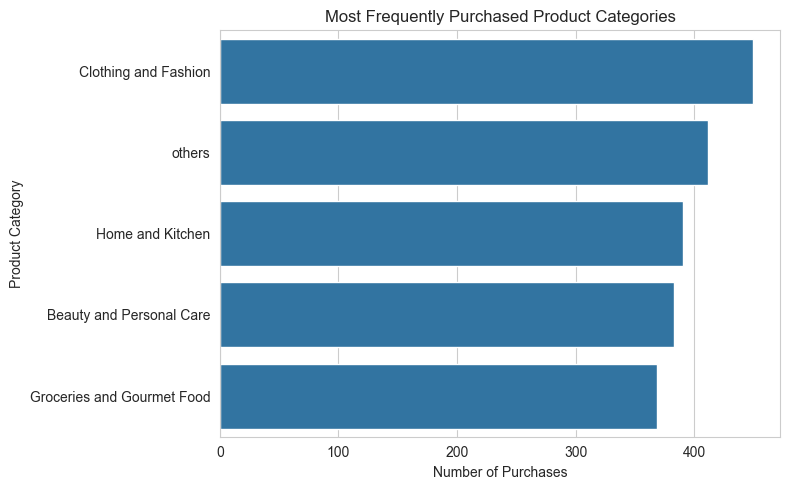

In [8]:
# Purchase Categories Analysis

exploded = df.copy()

exploded["Purchase_Categories_List"] = (
    exploded["Purchase_Categories"]
    .str.split(";")
)

exploded = exploded.explode("Purchase_Categories_List")

exploded["Purchase_Categories_List"] = (
    exploded["Purchase_Categories_List"]
    .str.strip()
)

category_counts = exploded["Purchase_Categories_List"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Most Frequently Purchased Product Categories")
plt.xlabel("Number of Purchases")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

**Insight:**
- Clothing and Fashion is the most frequently purchased product category,indicating strong customer demand in this segment.
- Home and Kitchen, Beauty and Personal Care, and Groceries and Gourmet Food also record high purchase volumes, suggesting that customers regularly shop
across multiple essential and lifestyle categories.
- The relatively small difference in purchase counts across categories indicates a well-distributed shopping pattern rather than heavy dependence
on a single product category.
- The presence of the 'Others' category among the top purchased categories suggests that customers also purchase products outside the primary
predefined categories, highlighting the diversity of customer preferences.